# Latent & Impdenace Loss Inverse Design

In [59]:
# Cell 1 - Project setup

import os
import sys
import time
import copy
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

PROJECT_ROOT = "/home/tekb/Master_Thesis_KB/CodesAndData"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Device:", device)

PROJECT_ROOT: /home/tekb/Master_Thesis_KB/CodesAndData
Device: cuda


In [60]:
# Cell 2 - Random-start inverse design configuration

INV_CFG = {
    # -----------------------------
    # Target
    # -----------------------------
    "target_sid": 109000,  # change to desired target SID

    # -----------------------------
    # Random-start setup
    # -----------------------------
    "start_mode": "random",
    "random_seed": 3,       # change this to get a different random start 1,2,3,4,5 are good seeds
    "exclude_target": True,   # do not allow target itself as start

    # -----------------------------
    # Stage-1 CNN-AE checkpoint
    # -----------------------------
    "stage1_checkpoint": os.path.join(
        PROJECT_ROOT,
        "checkpoints",
        "cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt",
    ),

    # -----------------------------
    # Stage-2 FNN checkpoint
    # -----------------------------
    "stage2_checkpoint": os.path.join(
        PROJECT_ROOT,
        "checkpoints",
        "stage2",
        "stage2_fnn_ln_phase_ld60_gelu_huber_adam_ep1500_lr0.0002_do0.06_hd(512, 512, 512, 512, 512, 256, 256).pt",
    ),

    # -----------------------------
    # Latent database
    # -----------------------------
    "latent_csv": os.path.join(
        PROJECT_ROOT,
        "Results",
        "latent_database_cnn_ln_phase_ld60_full20k",
        "latent_database_cnn_ln_phase_ld60_full20k.csv",
    ),

    "latent_npz": os.path.join(
        PROJECT_ROOT,
        "Results",
        "latent_database_cnn_ln_phase_ld60_full20k",
        "latent_database_cnn_ln_phase_ld60_full20k.npz",
    ),

    # -----------------------------
    # Impedance cache
    # -----------------------------
    "impedance_cache": os.path.join(
        PROJECT_ROOT,
        "Data",
        "stage2_impedance_cache_ln_phase_full20k.pt",
    ),

    # -----------------------------
    # Optimization setup
    # -----------------------------
    "opt_cols": [
        "TDIEL",
        "PERMITTIVITY",
        "XWIDTH",
        "YWIDTH",
        "A1_XCENTER",
        "A1_YCENTER",
    ],

    # For random start, 2000 is safer than 1000.
    # Early stopping will stop earlier if loss increases.
    "n_steps": 2000,
    "lr": 0.02,
    "print_every": 100,

    # output folder
    "results_dir": os.path.join(
        PROJECT_ROOT,
        "Results",
        "inverse_design_random_fnn_cnn_ae",
    ),
}

os.makedirs(INV_CFG["results_dir"], exist_ok=True)

print("Target SID:", INV_CFG["target_sid"])
print("Start mode:", INV_CFG["start_mode"])
print("Random seed:", INV_CFG["random_seed"])
print("Results dir:", INV_CFG["results_dir"])
print("Optimized columns:", INV_CFG["opt_cols"])

Target SID: 109000
Start mode: random
Random seed: 3
Results dir: /home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae
Optimized columns: ['TDIEL', 'PERMITTIVITY', 'XWIDTH', 'YWIDTH', 'A1_XCENTER', 'A1_YCENTER']


In [61]:
# Cell 3 - Project imports

from Sources.models import CNNAutoencoder
from Sources.stage2_models import build_stage2_model, count_trainable_parameters

In [62]:
# Cell 4 - Load latent database

latent_df = pd.read_csv(INV_CFG["latent_csv"])
latent_npz = np.load(INV_CFG["latent_npz"])

Z = latent_npz["latents"].astype(np.float32)      # [N, 60]
simu_ids = latent_npz["simu_ids"].astype(int)     # [N]
GEO = latent_npz["geometry"].astype(np.float32)   # [N, 17]
freq_hz_npz = latent_npz["freq_hz"].astype(np.float64)

z_cols = [f"z_{i}" for i in range(Z.shape[1])]

print("latent_df shape:", latent_df.shape)
print("Z shape:", Z.shape)
print("simu_ids shape:", simu_ids.shape)
print("GEO shape:", GEO.shape)

if "simu_index" not in latent_df.columns:
    raise ValueError("latent_df must contain simu_index column.")

if not np.all(latent_df["simu_index"].values.astype(int) == simu_ids):   # checks that CSV and NPZ have the same order
    raise ValueError("CSV simu_index and NPZ simu_ids order mismatch.")

print("Latent database loaded and verified.")

latent_df shape: (20000, 78)
Z shape: (20000, 60)
simu_ids shape: (20000,)
GEO shape: (20000, 17)
Latent database loaded and verified.


In [63]:
# Cell 5 - Load frozen Stage-1 CNN-AE

stage1_ckpt = torch.load(INV_CFG["stage1_checkpoint"], map_location=device)

ae = CNNAutoencoder(latent_dim=60).to(device)
ae.load_state_dict(stage1_ckpt["model_state"])
ae.eval()

for p in ae.parameters():
    p.requires_grad = False

if "stats" not in stage1_ckpt:
    raise KeyError("Stage-1 checkpoint has no stats.")

stats1 = stage1_ckpt["stats"]
stats1 = {
    k: v.to(device) if torch.is_tensor(v) else torch.tensor(v, dtype=torch.float32, device=device)
    for k, v in stats1.items()
}

print("Loaded frozen Stage-1 CNN-AE decoder.")
print("Stats keys:", list(stats1.keys()))

Loaded frozen Stage-1 CNN-AE decoder.
Stats keys: ['ch0_mean', 'ch0_std', 'ch1_mean', 'ch1_std']


/tmp/ipykernel_237848/2570866015.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stage1_ckpt = torch.load(INV_CFG["stage1_checkpoint"], map_location=device)


In [64]:
# Cell 6 - Load trained Stage-2 FNN checkpoint

stage2_ckpt_path = INV_CFG["stage2_checkpoint"]

if not os.path.exists(stage2_ckpt_path):
    raise FileNotFoundError(
        f"Stage-2 checkpoint not found:\n{stage2_ckpt_path}\n"
        "Please update INV_CFG['stage2_checkpoint']."
    )

stage2_ckpt = torch.load(stage2_ckpt_path, map_location=device)

stage2_cfg = stage2_ckpt["config"]
feature_cols = stage2_ckpt["feature_cols"]

print("Loaded Stage-2 checkpoint:")
print(stage2_ckpt_path)
print("Feature columns:", feature_cols)
print("Number of features:", len(feature_cols))
print("Stage-2 config keys:", stage2_cfg.keys())

Loaded Stage-2 checkpoint:
/home/tekb/Master_Thesis_KB/CodesAndData/checkpoints/stage2/stage2_fnn_ln_phase_ld60_gelu_huber_adam_ep1500_lr0.0002_do0.06_hd(512, 512, 512, 512, 512, 256, 256).pt
Feature columns: ['TDIEL', 'TMET', 'XWIDTH', 'YWIDTH', 'CONDUCTIVITY', 'PERMITTIVITY', 'LOSSTANGENT', 'A1_VIARADIUS', 'A1_ANTIPADRADIUS', 'A1_VIAPITCH', 'A1_XCENTER', 'A1_YCENTER', 'A2_VIARADIUS', 'A2_ANTIPADRADIUS', 'A2_VIAPITCH', 'A2_XCENTER', 'A2_YCENTER']
Number of features: 17
Stage-2 config keys: dict_keys(['model_type', 'latent_dim', 'repr', 'dataset_name', 'data_dir', 'parameter_csv', 'latent_csv', 'latent_npz', 'stage1_model_type', 'stage1_checkpoint', 'stage1_training_samples', 'stage1_loss', 'stage2_impedance_cache', 'train_fraction', 'val_fraction', 'test_fraction', 'split_seed', 'hidden_dims', 'activation', 'dropout', 'use_batchnorm', 'batch_size', 'epochs', 'optimizer', 'loss_function', 'huber_delta', 'lr', 'weight_decay', 'patience', 'min_delta', 'log_every', 'grad_clip', 'checkpoin

/tmp/ipykernel_237848/1712831120.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stage2_ckpt = torch.load(stage2_ckpt_path, map_location=device)


In [65]:
# Cell 7 - Rebuild and freeze Stage-2 FNN

model = build_stage2_model(
    model_type=stage2_cfg["model_type"],
    input_dim=len(feature_cols),
    latent_dim=stage2_cfg["latent_dim"],
    hidden_dims=stage2_cfg["hidden_dims"],
    activation=stage2_cfg["activation"],
    dropout=stage2_cfg["dropout"],
    use_batchnorm=stage2_cfg["use_batchnorm"],
).to(device)

model.load_state_dict(stage2_ckpt["model_state"])
model.eval()

for p in model.parameters():
    p.requires_grad = False   # freeze all parameters

print(model)
print("Trainable parameters after freezing:", count_trainable_parameters(model))

FNNStage2(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.06, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.06, inplace=False)
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.06, inplace=False)
    (9): Linear(in_features=512, out_features=512, bias=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.06, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): GELU(approximate='none')
    (14): Dropout(p=0.06, inplace=False)
    (15): Linear(in_features=512, out_features=256, bias=True)
    (16): GELU(approximate='none')
    (17): Dropout(p=0.06, inplace=False)
    (18): Linear(in_features=256, out_features=256, bias=True)
    (19): GELU(approximate='none')
    (20): Dropout(p=0.06, inplace=False)
    (2

In [66]:
# Cell 8 - Load Stage-2 input and latent scalers

x_mean = torch.as_tensor(stage2_ckpt["x_scaler_mean"], dtype=torch.float32, device=device)
x_scale = torch.as_tensor(stage2_ckpt["x_scaler_scale"], dtype=torch.float32, device=device)

z_mean = torch.as_tensor(stage2_ckpt["z_scaler_mean"], dtype=torch.float32, device=device)
z_scale = torch.as_tensor(stage2_ckpt["z_scaler_scale"], dtype=torch.float32, device=device)

print("x_mean shape:", x_mean.shape)
print("x_scale shape:", x_scale.shape)
print("z_mean shape:", z_mean.shape)
print("z_scale shape:", z_scale.shape)

x_mean shape: torch.Size([17])
x_scale shape: torch.Size([17])
z_mean shape: torch.Size([60])
z_scale shape: torch.Size([60])


In [67]:
# Cell 9 - Load impedance cache

cache_path = INV_CFG["impedance_cache"]

if not os.path.exists(cache_path):
    raise FileNotFoundError(
        f"Impedance cache not found:\n{cache_path}"
    )

imp_cache = torch.load(cache_path, map_location="cpu")

cache_sids = imp_cache["simu_ids"].cpu().numpy().astype(int)
sid_to_cache_pos = {int(s): i for i, s in enumerate(cache_sids)}

freq_hz = np.asarray(imp_cache["freq_hz"], dtype=np.float64)
freq_mhz = freq_hz / 1e6

print("Impedance shape:", imp_cache["impedance"].shape)
print("Frequency points:", len(freq_hz))
print("Cache SIDs:", cache_sids.shape)

Impedance shape: torch.Size([20000, 2, 334])
Frequency points: 334
Cache SIDs: (20000,)


/tmp/ipykernel_237848/734604136.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  imp_cache = torch.load(cache_path, map_location="cpu")


In [68]:
# Cell 10 - Build Stage-2 feature matrix X_raw

missing_features = [c for c in feature_cols if c not in latent_df.columns]

if missing_features:
    raise ValueError(
        f"These Stage-2 feature columns are missing from latent_df:\n{missing_features}"
    )

X_raw = latent_df[feature_cols].values.astype(np.float32)

print("X_raw shape:", X_raw.shape)
print("Feature columns:")
for i, col in enumerate(feature_cols):
    print(i, col)

X_raw shape: (20000, 17)
Feature columns:
0 TDIEL
1 TMET
2 XWIDTH
3 YWIDTH
4 CONDUCTIVITY
5 PERMITTIVITY
6 LOSSTANGENT
7 A1_VIARADIUS
8 A1_ANTIPADRADIUS
9 A1_VIAPITCH
10 A1_XCENTER
11 A1_YCENTER
12 A2_VIARADIUS
13 A2_ANTIPADRADIUS
14 A2_VIAPITCH
15 A2_XCENTER
16 A2_YCENTER


In [69]:
# Cell 11 - Select target PCB and random starting PCB

TARGET_SID = int(INV_CFG["target_sid"])

sid_to_row = {int(s): i for i, s in enumerate(simu_ids)}

if TARGET_SID not in sid_to_row:
    raise ValueError(f"TARGET_SID={TARGET_SID} not found in latent database.")

target_row = sid_to_row[TARGET_SID]

z_target_raw_np = Z[target_row]          # raw 60D latent of target
x_target_raw_np = X_raw[target_row]      # true geometry features of target

# --------------------------------------------------
# Random start selection
# --------------------------------------------------
rng = np.random.default_rng(int(INV_CFG["random_seed"]))

candidate_rows = np.arange(len(simu_ids))

if INV_CFG.get("exclude_target", True):
    candidate_rows = candidate_rows[candidate_rows != target_row]

random_start_row = int(rng.choice(candidate_rows))
random_start_sid = int(simu_ids[random_start_row])

z_random_start_raw_np = Z[random_start_row]
x_random_start_raw_np = X_raw[random_start_row]

# --------------------------------------------------
# Keeping old variable names so later cells work unchanged
# --------------------------------------------------
nearest_row = random_start_row
nearest_sid = random_start_sid

z_nearest_raw_np = z_random_start_raw_np
x_nearest_raw_np = x_random_start_raw_np

# Distance from every sample to target in raw 60D latent space
distances = np.linalg.norm(Z - z_target_raw_np[None, :], axis=1)
distances[target_row] = np.inf

random_start_latent_distance = float(distances[random_start_row])

print("Target SID:", TARGET_SID)
print("Target row:", target_row)

print("\nRandom start SID:", random_start_sid)
print("Random start row:", random_start_row)
print("Random start latent distance:", random_start_latent_distance)
print("Random seed:", INV_CFG["random_seed"])

print("\nTarget selected feature values:")
display(pd.DataFrame([x_target_raw_np], columns=feature_cols))

print("\nRandom-start feature values:")
display(pd.DataFrame([x_random_start_raw_np], columns=feature_cols))

Target SID: 109000
Target row: 9000

Random start SID: 116230
Random start row: 16230
Random start latent distance: 10.68878173828125
Random seed: 3

Target selected feature values:


,TDIEL,TMET,XWIDTH,YWIDTH,CONDUCTIVITY,PERMITTIVITY,LOSSTANGENT,A1_VIARADIUS,A1_ANTIPADRADIUS,A1_VIAPITCH,A1_XCENTER,A1_YCENTER,A2_VIARADIUS,A2_ANTIPADRADIUS,A2_VIAPITCH,A2_XCENTER,A2_YCENTER
0,29.0292,3.94943,5321.370117,15898.900391,54122100.0,5.60731,0.017807,9.0,16.0,40.0,2150.0,6950.0,5.0,16.0,40.0,1850.0,3550.0



Random-start feature values:


,TDIEL,TMET,XWIDTH,YWIDTH,CONDUCTIVITY,PERMITTIVITY,LOSSTANGENT,A1_VIARADIUS,A1_ANTIPADRADIUS,A1_VIAPITCH,A1_XCENTER,A1_YCENTER,A2_VIARADIUS,A2_ANTIPADRADIUS,A2_VIAPITCH,A2_XCENTER,A2_YCENTER
0,27.149401,3.68046,6386.350098,10108.599609,48962900.0,5.2817,0.020307,7.0,20.0,40.0,5600.0,7250.0,8.0,17.0,40.0,2400.0,5750.0


In [70]:
# Cell 11B - Create run-specific result folder

RUN_RESULTS_DIR = os.path.join(
    INV_CFG["results_dir"],
    f"target_{TARGET_SID}_start_{nearest_sid}"
)

os.makedirs(RUN_RESULTS_DIR, exist_ok=True)

print("Run results folder:")
print(RUN_RESULTS_DIR)

Run results folder:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230


In [71]:
# Cell 12 - Define raw bounds and normalized bounds

x_lower_raw_np = np.min(X_raw, axis=0).astype(np.float32)
x_upper_raw_np = np.max(X_raw, axis=0).astype(np.float32)

x_lower_raw = torch.as_tensor(x_lower_raw_np, dtype=torch.float32, device=device)
x_upper_raw = torch.as_tensor(x_upper_raw_np, dtype=torch.float32, device=device)

x_lower_norm = (x_lower_raw - x_mean) / (x_scale + 1e-12)
x_upper_norm = (x_upper_raw - x_mean) / (x_scale + 1e-12)

bounds_df = pd.DataFrame({
    "feature": feature_cols,
    "lower_raw": x_lower_raw_np,
    "upper_raw": x_upper_raw_np,
})

display(bounds_df)

,feature,lower_raw,upper_raw
0,TDIEL,3.001920e+00,7.899970e+01
1,TMET,7.001230e-01,4.099860e+00
2,XWIDTH,2.000150e+03,1.799960e+04
3,YWIDTH,2.000510e+03,1.799960e+04
4,CONDUCTIVITY,4.500000e+07,5.799950e+07
5,PERMITTIVITY,2.000010e+00,5.999990e+00
6,LOSSTANGENT,5.000900e-03,2.500000e-02
7,A1_VIARADIUS,5.000000e+00,9.000000e+00
8,A1_ANTIPADRADIUS,1.500000e+01,2.400000e+01
9,A1_VIAPITCH,4.000000e+01,4.000000e+01


In [72]:
# Cell 13 - Prepare optimized feature indices

opt_cols = INV_CFG["opt_cols"]

missing_opt = [c for c in opt_cols if c not in feature_cols]
if missing_opt:
    raise ValueError(
        f"These optimized columns are not in Stage-2 feature_cols:\n{missing_opt}"
    )

opt_idx = np.array([feature_cols.index(c) for c in opt_cols], dtype=int)

all_idx = np.arange(len(feature_cols))
fixed_idx = np.array([i for i in all_idx if i not in opt_idx], dtype=int)

print("Optimized columns:")
for i in opt_idx:
    print(i, feature_cols[i])

print("\nFixed columns:")
for i in fixed_idx:
    print(i, feature_cols[i])

Optimized columns:
0 TDIEL
5 PERMITTIVITY
2 XWIDTH
3 YWIDTH
10 A1_XCENTER
11 A1_YCENTER

Fixed columns:
1 TMET
4 CONDUCTIVITY
6 LOSSTANGENT
7 A1_VIARADIUS
8 A1_ANTIPADRADIUS
9 A1_VIAPITCH
12 A2_VIARADIUS
13 A2_ANTIPADRADIUS
14 A2_VIAPITCH
15 A2_XCENTER
16 A2_YCENTER


In [73]:
# Cell 14 - Helper functions

def raw_to_norm_torch(x_raw):
    return (x_raw - x_mean) / (x_scale + 1e-12)


def norm_to_raw_torch(x_norm):
    return x_norm * (x_scale + 1e-12) + x_mean


def project_design_to_valid_space(x_norm_design, x_norm_initial):
    """
    Enforce:
    1. Fixed variables stay fixed.
    2. Optimized variables stay inside dataset min/max bounds.
    3. A1 center remains inside the board if those columns exist.
    """
    with torch.no_grad():
        # Keep non-optimized variables fixed
        x_norm_design[fixed_idx] = x_norm_initial[fixed_idx]

        # Convert to raw for physical constraints
        x_raw = norm_to_raw_torch(x_norm_design)

        # Clamp optimized variables to raw dataset bounds
        for idx in opt_idx:
            x_raw[idx] = torch.clamp(
                x_raw[idx],
                min=x_lower_raw[idx],
                max=x_upper_raw[idx],
            )

        # Enforce A1_XCENTER inside XWIDTH if both exist
        if "A1_XCENTER" in feature_cols and "XWIDTH" in feature_cols:
            ix_a1x = feature_cols.index("A1_XCENTER")
            ix_xw = feature_cols.index("XWIDTH")

            if ix_a1x in opt_idx:
                x_raw[ix_a1x] = torch.clamp(
                    x_raw[ix_a1x],
                    min=x_lower_raw[ix_a1x],
                    max=torch.minimum(x_upper_raw[ix_a1x], x_raw[ix_xw]),
                )

        # Enforce A1_YCENTER inside YWIDTH if both exist
        if "A1_YCENTER" in feature_cols and "YWIDTH" in feature_cols:
            ix_a1y = feature_cols.index("A1_YCENTER")
            ix_yw = feature_cols.index("YWIDTH")

            if ix_a1y in opt_idx:
                x_raw[ix_a1y] = torch.clamp(
                    x_raw[ix_a1y],
                    min=x_lower_raw[ix_a1y],
                    max=torch.minimum(x_upper_raw[ix_a1y], x_raw[ix_yw]),
                )

        # Convert back to normalized space
        x_norm_projected = raw_to_norm_torch(x_raw)

        x_norm_design[:] = x_norm_projected[:]

    return x_norm_design


@torch.no_grad()
def predict_latent_from_raw_x(x_raw_np):
    """
    x_raw_np: [P]
    returns:
        z_pred_norm [60]
        z_pred_raw  [60]
    """
    x_raw = torch.as_tensor(x_raw_np, dtype=torch.float32, device=device)
    x_norm = raw_to_norm_torch(x_raw)

    z_pred_norm = model(x_norm.unsqueeze(0)).squeeze(0)
    z_pred_raw = z_pred_norm * (z_scale + 1e-12) + z_mean

    return z_pred_norm.cpu().numpy(), z_pred_raw.cpu().numpy()


@torch.no_grad()
def decode_z_raw_to_impedance(z_raw_np):
    """
    z_raw_np: [60] physical latent vector
    returns:
        mag_ohm [334]
        phase_rad [334]
        y_phys [2, 334]
    """
    z_raw = torch.as_tensor(z_raw_np, dtype=torch.float32, device=device).unsqueeze(0)

    y_norm = ae.decode(z_raw)

    y_phys = y_norm.clone()
    y_phys[:, 0, :] = (
        y_phys[:, 0, :] * (stats1["ch0_std"] + 1e-6)
        + stats1["ch0_mean"]
    )
    y_phys[:, 1, :] = (
        y_phys[:, 1, :] * (stats1["ch1_std"] + 1e-6)
        + stats1["ch1_mean"]
    )

    y_phys_np = y_phys.squeeze(0).cpu().numpy()

    mag_ohm = np.exp(y_phys_np[0])
    phase_rad = y_phys_np[1]

    return mag_ohm, phase_rad, y_phys_np


def get_true_impedance_by_sid(sid):
    sid = int(sid)
    pos = sid_to_cache_pos[sid]

    y = imp_cache["impedance"][pos].cpu().numpy()  # [2, 334]

    mag_ohm = np.exp(y[0])
    phase_rad = y[1]

    return mag_ohm, phase_rad, y


def mae_ohm(a, b):
    return float(np.mean(np.abs(a - b)))


def mae_db(a, b):
    a_db = 20.0 * np.log10(a + 1e-12)
    b_db = 20.0 * np.log10(b + 1e-12)
    return float(np.mean(np.abs(a_db - b_db)))

In [74]:
# Cell 15 - Check random starting point

target_mag, target_phase, target_y = get_true_impedance_by_sid(TARGET_SID)
nearest_true_mag, nearest_true_phase, nearest_true_y = get_true_impedance_by_sid(nearest_sid)

# FNN prediction from random geometry
z_start_norm_np, z_start_raw_np = predict_latent_from_raw_x(x_nearest_raw_np)
start_pred_mag, start_pred_phase, _ = decode_z_raw_to_impedance(z_start_raw_np)

print("Target SID:", TARGET_SID)
print("Random start SID:", nearest_sid)

print("\nTrue random vs target:")
print("MAE Ohm:", mae_ohm(target_mag, nearest_true_mag))
print("MAE dB :", mae_db(target_mag, nearest_true_mag))

print("\nFNN+Decoder prediction from random geometry vs target:")
print("MAE Ohm:", mae_ohm(target_mag, start_pred_mag))
print("MAE dB :", mae_db(target_mag, start_pred_mag))

Target SID: 109000
Random start SID: 116230

True random vs target:
MAE Ohm: 0.8100952506065369
MAE dB : 3.3790934085845947

FNN+Decoder prediction from random geometry vs target:
MAE Ohm: 0.72901850938797
MAE dB : 3.175661325454712


In [75]:
# Cell 16 - Inverse optimization from random start with early stopping

n_steps = int(INV_CFG["n_steps"])
lr = float(INV_CFG["lr"])
print_every = int(INV_CFG["print_every"])

# Early stopping settings
patience = 100          # stop if no improvement for 100 steps
min_delta = 1e-7        # minimum improvement required
best_loss = float("inf")
best_step = None
bad_steps = 0
best_x_design_norm = None

# Target latent in normalized space
z_target_raw = torch.as_tensor(z_target_raw_np, dtype=torch.float32, device=device)
z_target_norm = (z_target_raw - z_mean) / (z_scale + 1e-12)

# Initial design = random geometry
x0_raw = torch.as_tensor(x_nearest_raw_np, dtype=torch.float32, device=device)
x0_norm = raw_to_norm_torch(x0_raw).detach()

# This is the trainable geometry variable in normalized space
x_design_norm = x0_norm.clone().detach()
x_design_norm.requires_grad_(True)

# Optimizer updates geometry only
optimizer = torch.optim.Adam([x_design_norm], lr=lr)

history = {
    "step": [],
    "latent_mse": [],
    "latent_l2_norm": [],
}

t0 = time.time()

for step in range(1, n_steps + 1):
    optimizer.zero_grad()

    # Pass optimized normalized geometry through frozen FNN
    z_pred_norm = model(x_design_norm.unsqueeze(0)).squeeze(0)

    # Latent-space loss
    latent_mse = torch.mean((z_pred_norm - z_target_norm) ** 2)
    latent_l2 = torch.linalg.norm(z_pred_norm - z_target_norm)

    loss = latent_mse
    loss.backward()

    # Prevent fixed features from getting updated
    with torch.no_grad():
        if x_design_norm.grad is not None:
            x_design_norm.grad[fixed_idx] = 0.0

    optimizer.step()

    # Project back into valid design space
    project_design_to_valid_space(x_design_norm, x0_norm)

    current_loss = float(latent_mse.detach().cpu())
    current_l2 = float(latent_l2.detach().cpu())

    history["step"].append(step)
    history["latent_mse"].append(current_loss)
    history["latent_l2_norm"].append(current_l2)

    # ---------------- Early stopping check ----------------
    if current_loss < best_loss - min_delta:
        best_loss = current_loss
        best_step = step
        bad_steps = 0
        best_x_design_norm = x_design_norm.detach().clone()
    else:
        bad_steps += 1

    if step == 1 or step % print_every == 0:
        print(
            f"Step {step:04d}/{n_steps} | "
            f"latent_mse={current_loss:.6e} | "
            f"latent_l2={current_l2:.6f} | "
            f"best_step={best_step} | "
            f"bad_steps={bad_steps}/{patience}"
        )

    if bad_steps >= patience:
        print(
            f"\nEarly stopping at step {step}. "
            f"Best step: {best_step}, best latent MSE: {best_loss:.6e}"
        )
        break

elapsed = time.time() - t0

# Restore best geometry found during optimization
if best_x_design_norm is not None:
    with torch.no_grad():
        x_design_norm[:] = best_x_design_norm[:]

actual_steps = history["step"][-1]

print("\nOptimization finished.")
print("Time sec:", elapsed)
print("Actual steps:", actual_steps)
print("Best step:", best_step)
print("Initial latent MSE:", history["latent_mse"][0])
print("Final latent MSE:", history["latent_mse"][-1])
print("Best latent MSE:", best_loss)
print("Initial latent L2:", history["latent_l2_norm"][0])
print("Final latent L2:", history["latent_l2_norm"][-1])

Step 0001/2000 | latent_mse=8.671351e-01 | latent_l2=7.213051 | best_step=1 | bad_steps=0/100
Step 0100/2000 | latent_mse=7.275984e-01 | latent_l2=6.607261 | best_step=100 | bad_steps=0/100
Step 0200/2000 | latent_mse=7.100646e-01 | latent_l2=6.527164 | best_step=200 | bad_steps=0/100
Step 0300/2000 | latent_mse=7.045450e-01 | latent_l2=6.501746 | best_step=300 | bad_steps=0/100
Step 0400/2000 | latent_mse=7.036146e-01 | latent_l2=6.497451 | best_step=400 | bad_steps=0/100
Step 0500/2000 | latent_mse=7.034674e-01 | latent_l2=6.496772 | best_step=500 | bad_steps=0/100
Step 0600/2000 | latent_mse=7.034460e-01 | latent_l2=6.496673 | best_step=600 | bad_steps=0/100
Step 0700/2000 | latent_mse=7.034434e-01 | latent_l2=6.496661 | best_step=685 | bad_steps=15/100
Step 0800/2000 | latent_mse=7.034431e-01 | latent_l2=6.496660 | best_step=773 | bad_steps=27/100

Early stopping at step 873. Best step: 773, best latent MSE: 7.034431e-01

Optimization finished.
Time sec: 0.5700497627258301
Actual s

In [76]:
# Cell 16B - Inverse optimization using impedance-domain loss

n_steps_imp = int(INV_CFG["n_steps"])
lr_imp = float(INV_CFG["lr"])
print_every_imp = int(INV_CFG["print_every"])

# Early stopping settings
patience_imp = 100
min_delta_imp = 1e-7

# Impedance loss weights
phase_weight_imp = 0.001

# --------------------------------------------------
# Target impedance from cache
# target_y was created earlier by:
# target_mag, target_phase, target_y = get_true_impedance_by_sid(TARGET_SID)
# target_y shape: [2, 334]
# --------------------------------------------------
target_y_torch = torch.as_tensor(target_y, dtype=torch.float32, device=device)

target_lnmag = target_y_torch[0]      # ln(|Z|)
target_phase_rad = target_y_torch[1]  # phase in radians

# Convert ln(|Z|) to dB:
# 20*log10(|Z|) = 20*ln(|Z|)/ln(10)
target_mag_db = 20.0 * target_lnmag / np.log(10.0)

# --------------------------------------------------
# Initial design = nearest-neighbor geometry
# --------------------------------------------------
x0_raw_imp = torch.as_tensor(x_nearest_raw_np, dtype=torch.float32, device=device)
x0_norm_imp = raw_to_norm_torch(x0_raw_imp).detach()

# Trainable normalized geometry for impedance-loss optimization
x_design_norm_imp = x0_norm_imp.clone().detach()
x_design_norm_imp.requires_grad_(True)

# Optimizer updates geometry only
optimizer_imp = torch.optim.Adam([x_design_norm_imp], lr=lr_imp)

history_imp = {
    "step": [],
    "loss_total": [],
    "loss_mag_db_mse": [],
    "loss_phase_deg_mse": [],
}

best_loss_imp = float("inf")
best_step_imp = None
bad_steps_imp = 0
best_x_design_norm_imp = None

t0_imp = time.time()

for step in range(1, n_steps_imp + 1):
    optimizer_imp.zero_grad()

    # --------------------------------------------------
    # geometry -> frozen Stage-2 FNN -> normalized latent
    # --------------------------------------------------
    z_pred_norm_imp = model(x_design_norm_imp.unsqueeze(0))  # [1, 60]

    # normalized latent -> raw latent
    z_pred_raw_imp = z_pred_norm_imp * (z_scale + 1e-12) + z_mean

    # --------------------------------------------------
    # raw latent -> frozen CNN-AE decoder -> normalized ln_phase
    # --------------------------------------------------
    y_pred_norm_imp = ae.decode(z_pred_raw_imp).squeeze(0)  # [2, 334]

    # Denormalize decoder output to physical ln(|Z|), phase
    pred_lnmag = (
        y_pred_norm_imp[0] * (stats1["ch0_std"] + 1e-6)
        + stats1["ch0_mean"]
    )

    pred_phase_rad = (
        y_pred_norm_imp[1] * (stats1["ch1_std"] + 1e-6)
        + stats1["ch1_mean"]
    )

    # Convert predicted ln(|Z|) to dB
    pred_mag_db = 20.0 * pred_lnmag / np.log(10.0)

    # --------------------------------------------------
    # Impedance-domain loss
    # --------------------------------------------------

    # Magnitude loss in dB domain
    loss_mag_db_mse = torch.mean((pred_mag_db - target_mag_db) ** 2)

    # Phase loss with wrapping to [-pi, pi]
    phase_diff = pred_phase_rad - target_phase_rad
    phase_diff = torch.atan2(torch.sin(phase_diff), torch.cos(phase_diff))
    phase_diff_deg = phase_diff * 180.0 / np.pi

    loss_phase_deg_mse = torch.mean(phase_diff_deg ** 2)

    # Total loss
    loss_imp = loss_mag_db_mse + phase_weight_imp * loss_phase_deg_mse

    loss_imp.backward()

    # Prevent fixed features from getting updated
    with torch.no_grad():
        if x_design_norm_imp.grad is not None:
            x_design_norm_imp.grad[fixed_idx] = 0.0

    optimizer_imp.step()

    # Project back into valid design space
    project_design_to_valid_space(x_design_norm_imp, x0_norm_imp)

    current_loss_imp = float(loss_imp.detach().cpu())
    current_mag_loss_imp = float(loss_mag_db_mse.detach().cpu())
    current_phase_loss_imp = float(loss_phase_deg_mse.detach().cpu())

    history_imp["step"].append(step)
    history_imp["loss_total"].append(current_loss_imp)
    history_imp["loss_mag_db_mse"].append(current_mag_loss_imp)
    history_imp["loss_phase_deg_mse"].append(current_phase_loss_imp)

    # Early stopping
    if current_loss_imp < best_loss_imp - min_delta_imp:
        best_loss_imp = current_loss_imp
        best_step_imp = step
        bad_steps_imp = 0
        best_x_design_norm_imp = x_design_norm_imp.detach().clone()
    else:
        bad_steps_imp += 1

    if step == 1 or step % print_every_imp == 0:
        print(
            f"Step {step:04d}/{n_steps_imp} | "
            f"total_loss={current_loss_imp:.6e} | "
            f"mag_db_mse={current_mag_loss_imp:.6e} | "
            f"phase_deg_mse={current_phase_loss_imp:.6e} | "
            f"best_step={best_step_imp} | "
            f"bad_steps={bad_steps_imp}/{patience_imp}"
        )

    if bad_steps_imp >= patience_imp:
        print(
            f"\nEarly stopping at step {step}. "
            f"Best step={best_step_imp}, best total loss={best_loss_imp:.6e}"
        )
        break

elapsed_imp = time.time() - t0_imp

# Restore best geometry
if best_x_design_norm_imp is not None:
    with torch.no_grad():
        x_design_norm_imp[:] = best_x_design_norm_imp[:]

actual_steps_imp = history_imp["step"][-1]

print("\nImpedance-loss optimization finished.")
print("Time sec:", elapsed_imp)
print("Actual steps:", actual_steps_imp)
print("Best step:", best_step_imp)
print("Initial total loss:", history_imp["loss_total"][0])
print("Final total loss:", history_imp["loss_total"][-1])
print("Best total loss:", best_loss_imp)

Step 0001/2000 | total_loss=1.710175e+01 | mag_db_mse=1.647273e+01 | phase_deg_mse=6.290228e+02 | best_step=1 | bad_steps=0/100
Step 0100/2000 | total_loss=4.420485e+00 | mag_db_mse=4.224446e+00 | phase_deg_mse=1.960386e+02 | best_step=98 | bad_steps=2/100
Step 0200/2000 | total_loss=4.371169e+00 | mag_db_mse=4.176562e+00 | phase_deg_mse=1.946070e+02 | best_step=198 | bad_steps=2/100
Step 0300/2000 | total_loss=4.346689e+00 | mag_db_mse=4.152913e+00 | phase_deg_mse=1.937764e+02 | best_step=268 | bad_steps=32/100
Step 0400/2000 | total_loss=4.346816e+00 | mag_db_mse=4.153057e+00 | phase_deg_mse=1.937588e+02 | best_step=369 | bad_steps=31/100

Early stopping at step 469. Best step=369, best total loss=4.345901e+00

Impedance-loss optimization finished.
Time sec: 0.4980583190917969
Actual steps: 469
Best step: 369
Initial total loss: 17.10175323486328
Final total loss: 4.348796844482422
Best total loss: 4.3459014892578125


In [77]:
# Cell 17 - Convert optimized normalized geometry to raw geometry

with torch.no_grad():
    # optimized geometry in normalized Stage-2 input space
    x_opt_norm = x_design_norm.detach().clone()

    # convert back to raw physical feature values
    x_opt_raw = norm_to_raw_torch(x_opt_norm).cpu().numpy()

print("Optimized raw geometry created.")
print("x_opt_raw shape:", x_opt_raw.shape)

design_compare_df = pd.DataFrame({
    "feature": feature_cols,
    "target_geometry": x_target_raw_np,
    "random_start_geometry": x_nearest_raw_np,
    "optimized_geometry": x_opt_raw,
    "was_optimized": [c in opt_cols for c in feature_cols],
})

display(design_compare_df)

save_csv = os.path.join(
    RUN_RESULTS_DIR,
    "geometry_latent_loss.csv",

)

design_compare_df.to_csv(save_csv, index=False)

print("Saved geometry comparison:")
print(save_csv)

Optimized raw geometry created.
x_opt_raw shape: (17,)


,feature,target_geometry,random_start_geometry,optimized_geometry,was_optimized
0,TDIEL,2.902920e+01,2.714940e+01,1.737153e+01,True
1,TMET,3.949430e+00,3.680460e+00,3.680460e+00,False
2,XWIDTH,5.321370e+03,6.386350e+03,9.526971e+03,True
3,YWIDTH,1.589890e+04,1.010860e+04,1.430765e+04,True
4,CONDUCTIVITY,5.412210e+07,4.896290e+07,4.896290e+07,False
5,PERMITTIVITY,5.607310e+00,5.281700e+00,2.474915e+00,True
6,LOSSTANGENT,1.780730e-02,2.030720e-02,2.030720e-02,False
7,A1_VIARADIUS,9.000000e+00,7.000000e+00,7.000000e+00,False
8,A1_ANTIPADRADIUS,1.600000e+01,2.000000e+01,2.000000e+01,False
9,A1_VIAPITCH,4.000000e+01,4.000000e+01,4.000000e+01,False


Saved geometry comparison:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/geometry_latent_loss.csv


In [78]:
# Cell 17B - Convert impedance-loss optimized geometry to raw geometry

with torch.no_grad():
    x_opt_norm_imp = x_design_norm_imp.detach().clone()
    x_opt_raw_imp = norm_to_raw_torch(x_opt_norm_imp).cpu().numpy()

print("Impedance-loss optimized raw geometry created.")
print("x_opt_raw_imp shape:", x_opt_raw_imp.shape)

design_compare_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "target_geometry": x_target_raw_np,
    "random_start_geometry": x_nearest_raw_np,
    "optimized_geometry_impedance_loss": x_opt_raw_imp,
    "was_optimized": [c in opt_cols for c in feature_cols],
})

display(design_compare_imp_df)

save_csv_imp = os.path.join(
    RUN_RESULTS_DIR,
    "geometry_impedance_loss.csv",
)

design_compare_imp_df.to_csv(save_csv_imp, index=False)

print("Saved impedance-loss geometry comparison:")
print(save_csv_imp)

Impedance-loss optimized raw geometry created.
x_opt_raw_imp shape: (17,)


,feature,target_geometry,random_start_geometry,optimized_geometry_impedance_loss,was_optimized
0,TDIEL,2.902920e+01,2.714940e+01,2.586061e+01,True
1,TMET,3.949430e+00,3.680460e+00,3.680460e+00,False
2,XWIDTH,5.321370e+03,6.386350e+03,7.567522e+03,True
3,YWIDTH,1.589890e+04,1.010860e+04,1.019289e+04,True
4,CONDUCTIVITY,5.412210e+07,4.896290e+07,4.896290e+07,False
5,PERMITTIVITY,5.607310e+00,5.281700e+00,5.999990e+00,True
6,LOSSTANGENT,1.780730e-02,2.030720e-02,2.030720e-02,False
7,A1_VIARADIUS,9.000000e+00,7.000000e+00,7.000000e+00,False
8,A1_ANTIPADRADIUS,1.600000e+01,2.000000e+01,2.000000e+01,False
9,A1_VIAPITCH,4.000000e+01,4.000000e+01,4.000000e+01,False


Saved impedance-loss geometry comparison:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/geometry_impedance_loss.csv


In [79]:
# Cell 18 - Decode optimized geometry and compare impedance

# Stage-2 FNN prediction from optimized geometry
z_opt_norm_np, z_opt_raw_np = predict_latent_from_raw_x(x_opt_raw)

opt_pred_mag, opt_pred_phase, opt_y = decode_z_raw_to_impedance(z_opt_raw_np)

# Metrics
start_true_mae_ohm = mae_ohm(target_mag, nearest_true_mag)
start_true_mae_db = mae_db(target_mag, nearest_true_mag)

start_pred_mae_ohm = mae_ohm(target_mag, start_pred_mag)
start_pred_mae_db = mae_db(target_mag, start_pred_mag)

opt_pred_mae_ohm = mae_ohm(target_mag, opt_pred_mag)
opt_pred_mae_db = mae_db(target_mag, opt_pred_mag)

print("Comparison with target true impedance")
print("------------------------------------")
print(f"Random start true impedance MAE    : {start_true_mae_ohm:.6f} Ohm | {start_true_mae_db:.6f} dB")
print(f"Random start FNN+decoder MAE       : {start_pred_mae_ohm:.6f} Ohm | {start_pred_mae_db:.6f} dB")
print(f"Optimized FNN+decoder MAE     : {opt_pred_mae_ohm:.6f} Ohm | {opt_pred_mae_db:.6f} dB")

metrics_dict = {
    "target_sid": int(TARGET_SID),
    "nearest_start_sid": int(nearest_sid),
    "nearest_latent_distance_raw": float(distances[nearest_row]),
    "initial_latent_mse": float(history["latent_mse"][0]),
    "final_latent_mse": float(history["latent_mse"][-1]),
    "initial_latent_l2": float(history["latent_l2_norm"][0]),
    "final_latent_l2": float(history["latent_l2_norm"][-1]),
    "nearest_true_mae_ohm": float(start_true_mae_ohm),
    "nearest_true_mae_db": float(start_true_mae_db),
    "nearest_fnn_decoder_mae_ohm": float(start_pred_mae_ohm),
    "nearest_fnn_decoder_mae_db": float(start_pred_mae_db),
    "optimized_fnn_decoder_mae_ohm": float(opt_pred_mae_ohm),
    "optimized_fnn_decoder_mae_db": float(opt_pred_mae_db),
    "optimized_columns": opt_cols,
    "n_steps": int(n_steps),
    "lr": float(lr),
    "optimization_time_sec": float(elapsed),
}

save_json = os.path.join(
    RUN_RESULTS_DIR,
      "metrics_latent_loss.json",

)

with open(save_json, "w") as f:
    json.dump(metrics_dict, f, indent=2)

print("\nSaved metrics:")
print(save_json)

Comparison with target true impedance
------------------------------------
Random start true impedance MAE    : 0.810095 Ohm | 3.379093 dB
Random start FNN+decoder MAE       : 0.729019 Ohm | 3.175661 dB
Optimized FNN+decoder MAE     : 0.568341 Ohm | 2.765016 dB

Saved metrics:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/metrics_latent_loss.json


In [80]:
# Cell 18B - Decode impedance-loss optimized geometry and compare impedance

z_opt_norm_imp_np, z_opt_raw_imp_np = predict_latent_from_raw_x(x_opt_raw_imp)

opt_imp_pred_mag, opt_imp_pred_phase, opt_imp_y = decode_z_raw_to_impedance(
    z_opt_raw_imp_np
)

# Metrics
nearest_true_mae_ohm = mae_ohm(target_mag, nearest_true_mag)
nearest_true_mae_db = mae_db(target_mag, nearest_true_mag)

nearest_fnn_mae_ohm = mae_ohm(target_mag, start_pred_mag)
nearest_fnn_mae_db = mae_db(target_mag, start_pred_mag)

opt_imp_mae_ohm = mae_ohm(target_mag, opt_imp_pred_mag)
opt_imp_mae_db = mae_db(target_mag, opt_imp_pred_mag)

print("Comparison with target true impedance")
print("------------------------------------")
print(
    f"Random start true impedance MAE              : "
    f"{nearest_true_mae_ohm:.6f} Ohm | {nearest_true_mae_db:.6f} dB"
)
print(
    f"Random start FNN+decoder MAE                 : "
    f"{nearest_fnn_mae_ohm:.6f} Ohm | {nearest_fnn_mae_db:.6f} dB"
)
print(
    f"Optimized FNN+decoder impedance-loss    : "
    f"{opt_imp_mae_ohm:.6f} Ohm | {opt_imp_mae_db:.6f} dB"
)

metrics_imp_dict = {
    "target_sid": int(TARGET_SID),
    "nearest_start_sid": int(nearest_sid),
    "loss_type": "impedance_domain_loss",
    "nearest_latent_distance_raw": float(distances[nearest_row]),

    "nearest_true_mae_ohm": float(nearest_true_mae_ohm),
    "nearest_true_mae_db": float(nearest_true_mae_db),

    "nearest_fnn_decoder_mae_ohm": float(nearest_fnn_mae_ohm),
    "nearest_fnn_decoder_mae_db": float(nearest_fnn_mae_db),

    "optimized_impedance_loss_mae_ohm": float(opt_imp_mae_ohm),
    "optimized_impedance_loss_mae_db": float(opt_imp_mae_db),

    "optimized_columns": opt_cols,
    "n_steps_max": int(n_steps_imp),
    "actual_steps": int(actual_steps_imp),
    "best_step": int(best_step_imp),
    "best_total_loss": float(best_loss_imp),
    "phase_weight": float(phase_weight_imp),
    "lr": float(lr_imp),
    "optimization_time_sec": float(elapsed_imp),
}

save_json_imp = os.path.join(
    RUN_RESULTS_DIR,
    "metrics_impedance_loss.json",
)

with open(save_json_imp, "w") as f:
    json.dump(metrics_imp_dict, f, indent=2)

print("\nSaved impedance-loss metrics:")
print(save_json_imp)

Comparison with target true impedance
------------------------------------
Random start true impedance MAE              : 0.810095 Ohm | 3.379093 dB
Random start FNN+decoder MAE                 : 0.729019 Ohm | 3.175661 dB
Optimized FNN+decoder impedance-loss    : 0.322493 Ohm | 1.527919 dB

Saved impedance-loss metrics:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/metrics_impedance_loss.json


Saved latent MSE loss plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/latent_mse_loss.png


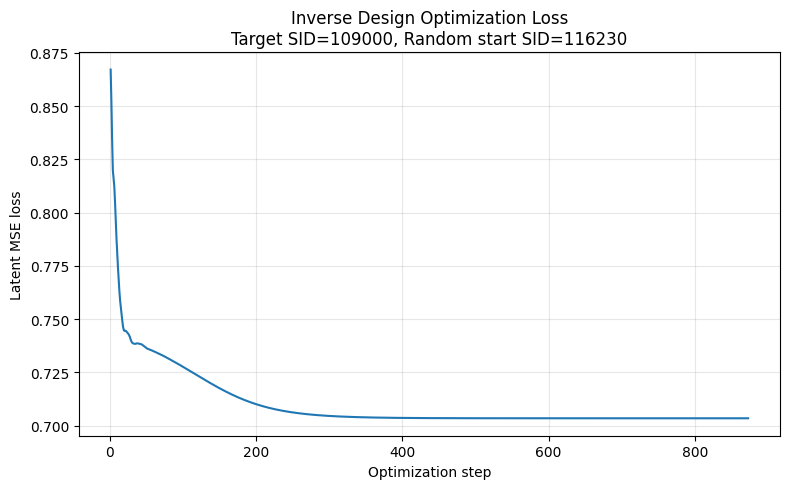

Saved latent L2 distance plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/latent_l2_distance.png


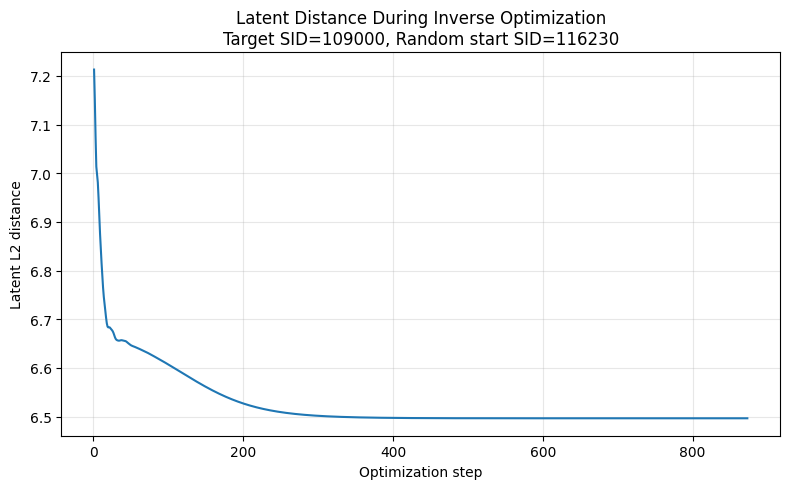

In [81]:
# Cell 19 - Plot and save latent-loss optimization history

# -----------------------------
# 1) Latent MSE loss plot
# -----------------------------
loss_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "latent_mse_loss.png"
)

plt.figure(figsize=(8, 5))
plt.plot(history["step"], history["latent_mse"])
plt.xlabel("Optimization step")
plt.ylabel("Latent MSE loss")
plt.title(
    f"Inverse Design Optimization Loss\n"
    f"Target SID={TARGET_SID}, Random start SID={nearest_sid}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
print("Saved latent MSE loss plot:")
print(loss_fig_path)

plt.show()


# -----------------------------
# 2) Latent L2 distance plot
# -----------------------------
l2_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "latent_l2_distance.png"
)

plt.figure(figsize=(8, 5))
plt.plot(history["step"], history["latent_l2_norm"])
plt.xlabel("Optimization step")
plt.ylabel("Latent L2 distance")
plt.title(
    f"Latent Distance During Inverse Optimization\n"
    f"Target SID={TARGET_SID}, Random start SID={nearest_sid}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(l2_fig_path, dpi=300, bbox_inches="tight")
print("Saved latent L2 distance plot:")
print(l2_fig_path)

plt.show()

Saved impedance-loss history plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/impedance_loss_total.png


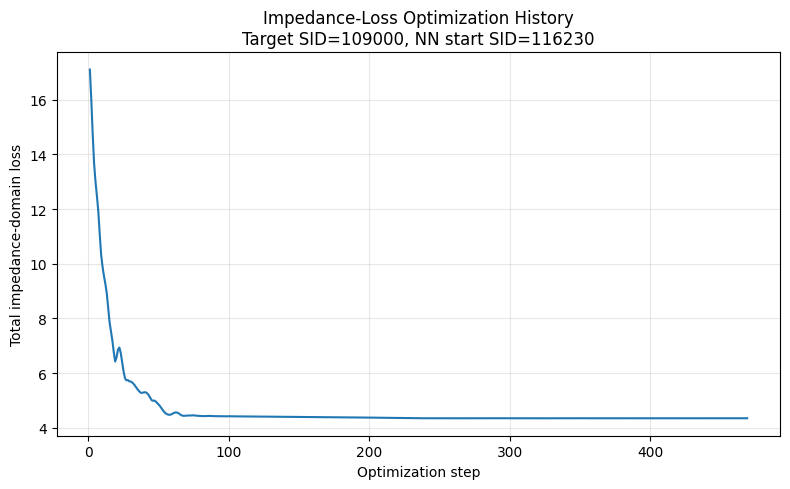

Saved magnitude dB loss plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/mag_db_mse_loss.png


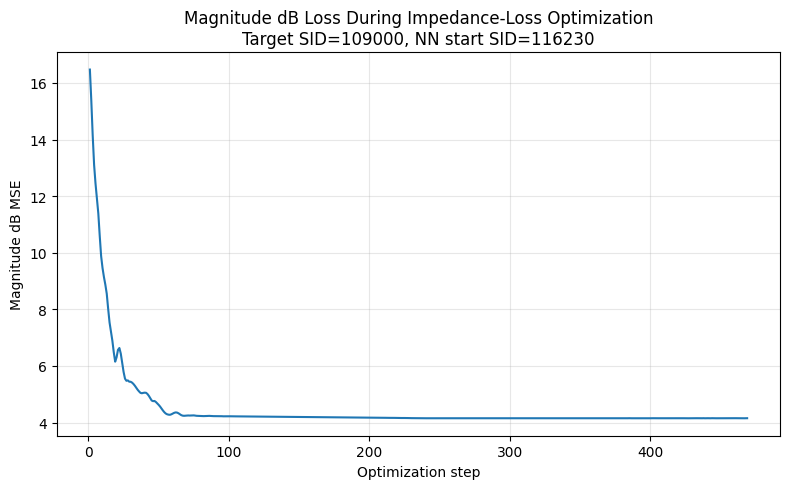

Saved phase loss plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/phase_deg_mse_loss.png


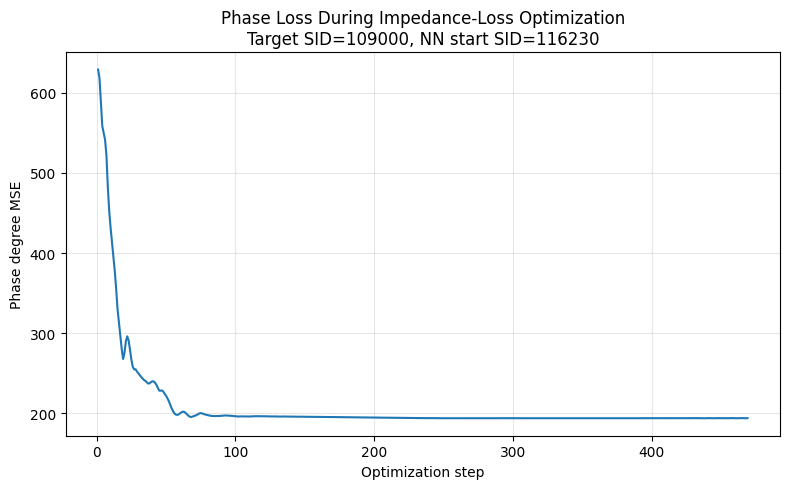

In [82]:
# Cell 19B - Plot and save impedance-loss optimization history

imp_loss_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "impedance_loss_total.png"
)

plt.figure(figsize=(8, 5))
plt.plot(history_imp["step"], history_imp["loss_total"])
plt.xlabel("Optimization step")
plt.ylabel("Total impedance-domain loss")
plt.title(
    f"Impedance-Loss Optimization History\n"
    f"Target SID={TARGET_SID}, NN start SID={nearest_sid}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(imp_loss_fig_path, dpi=300, bbox_inches="tight")
print("Saved impedance-loss history plot:")
print(imp_loss_fig_path)

plt.show()


# Magnitude dB MSE history
mag_loss_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "mag_db_mse_loss.png"
)

plt.figure(figsize=(8, 5))
plt.plot(history_imp["step"], history_imp["loss_mag_db_mse"])
plt.xlabel("Optimization step")
plt.ylabel("Magnitude dB MSE")
plt.title(
    f"Magnitude dB Loss During Impedance-Loss Optimization\n"
    f"Target SID={TARGET_SID}, NN start SID={nearest_sid}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(mag_loss_fig_path, dpi=300, bbox_inches="tight")
print("Saved magnitude dB loss plot:")
print(mag_loss_fig_path)

plt.show()


# Phase MSE history
phase_loss_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "phase_deg_mse_loss.png"
)

plt.figure(figsize=(8, 5))
plt.plot(history_imp["step"], history_imp["loss_phase_deg_mse"])
plt.xlabel("Optimization step")
plt.ylabel("Phase degree MSE")
plt.title(
    f"Phase Loss During Impedance-Loss Optimization\n"
    f"Target SID={TARGET_SID}, NN start SID={nearest_sid}"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(phase_loss_fig_path, dpi=300, bbox_inches="tight")
print("Saved phase loss plot:")
print(phase_loss_fig_path)

plt.show()

Saved magnitude plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/magnitude_latent_loss.png


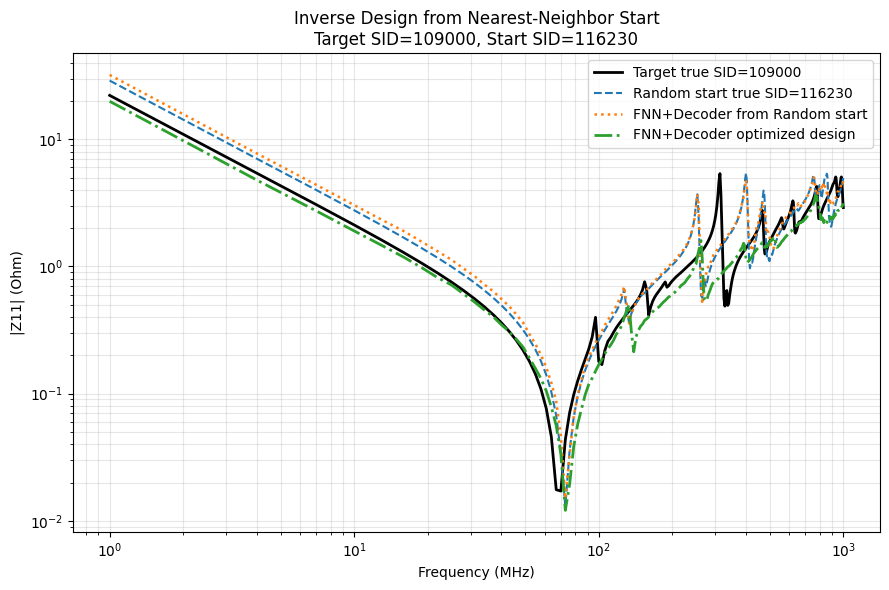

In [83]:
# Cell 20 - Plot target, random start, and optimized predicted impedance

mag_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "magnitude_latent_loss.png"
)

plt.figure(figsize=(9, 6))

plt.loglog(
    freq_mhz,
    target_mag,
    "k-",
    linewidth=2.0,
    label=f"Target true SID={TARGET_SID}",
)

plt.loglog(
    freq_mhz,
    nearest_true_mag,
    "--",
    linewidth=1.5,
    label=f"Random start true SID={nearest_sid}",
)

plt.loglog(
    freq_mhz,
    start_pred_mag,
    ":",
    linewidth=1.8,
    label="FNN+Decoder from Random start",
)

plt.loglog(
    freq_mhz,
    opt_pred_mag,
    "-.",
    linewidth=2.0,
    label="FNN+Decoder optimized design",
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ohm)")
plt.title(
    f"Inverse Design from Nearest-Neighbor Start\n"
    f"Target SID={TARGET_SID}, Start SID={nearest_sid}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(mag_fig_path, dpi=300, bbox_inches="tight")
print("Saved magnitude plot:")
print(mag_fig_path)

plt.show()

Saved comparison magnitude plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/latent_vs_impedance_loss_magnitude.png


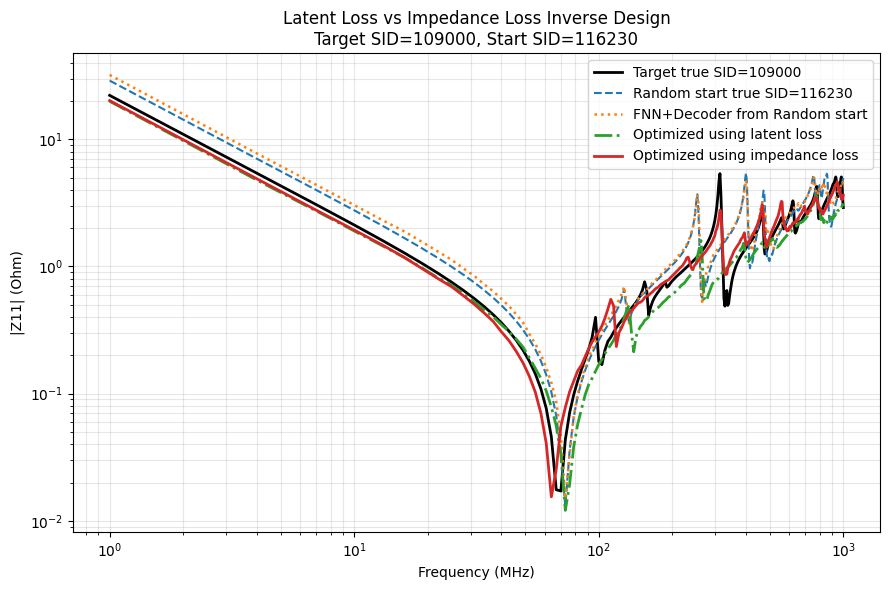

In [84]:
# Cell 20B - Compare latent-loss optimization vs impedance-loss optimization

compare_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "latent_vs_impedance_loss_magnitude.png"
)

plt.figure(figsize=(9, 6))

plt.loglog(
    freq_mhz,
    target_mag,
    "k-",
    linewidth=2.0,
    label=f"Target true SID={TARGET_SID}",
)

plt.loglog(
    freq_mhz,
    nearest_true_mag,
    "--",
    linewidth=1.5,
    label=f"Random start true SID={nearest_sid}",
)

plt.loglog(
    freq_mhz,
    start_pred_mag,
    ":",
    linewidth=1.8,
    label="FNN+Decoder from Random start",
)

plt.loglog(
    freq_mhz,
    opt_pred_mag,
    "-.",
    linewidth=2.0,
    label="Optimized using latent loss",
)

plt.loglog(
    freq_mhz,
    opt_imp_pred_mag,
    "-",
    linewidth=2.0,
    label="Optimized using impedance loss",
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ohm)")
plt.title(
    f"Latent Loss vs Impedance Loss Inverse Design\n"
    f"Target SID={TARGET_SID}, Start SID={nearest_sid}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(compare_fig_path, dpi=300, bbox_inches="tight")
print("Saved comparison magnitude plot:")
print(compare_fig_path)

plt.show()

Saved phase plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/phase_latent_loss.png


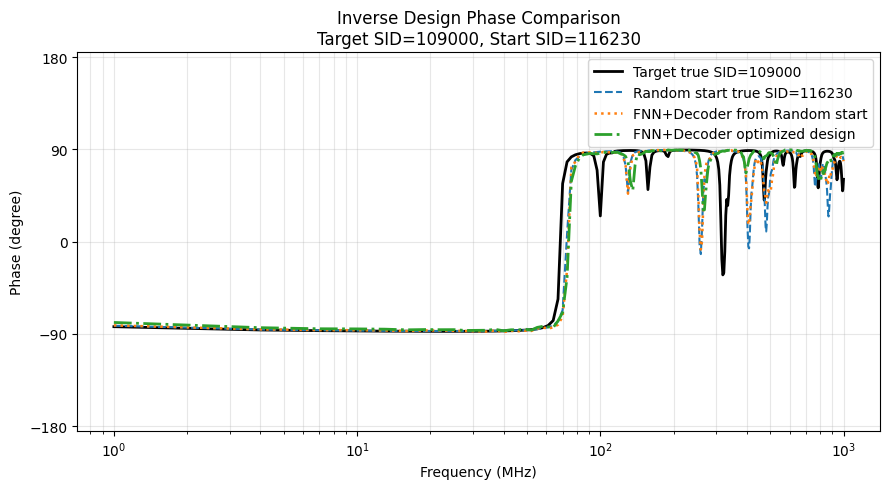

In [85]:
# Cell 21 - Plot phase comparison

phase_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "phase_latent_loss.png"
)

plt.figure(figsize=(9, 5))

plt.semilogx(
    freq_mhz,
    np.rad2deg(target_phase),
    "k-",
    linewidth=2.0,
    label=f"Target true SID={TARGET_SID}",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(nearest_true_phase),
    "--",
    linewidth=1.5,
    label=f"Random start true SID={nearest_sid}",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(start_pred_phase),
    ":",
    linewidth=1.8,
    label="FNN+Decoder from Random start",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(opt_pred_phase),
    "-.",
    linewidth=2.0,
    label="FNN+Decoder optimized design",
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Phase (degree)")
plt.ylim(-185, 185)
plt.yticks([-180, -90, 0, 90, 180])
plt.title(
    f"Inverse Design Phase Comparison\n"
    f"Target SID={TARGET_SID}, Start SID={nearest_sid}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(phase_fig_path, dpi=300, bbox_inches="tight")
print("Saved phase plot:")
print(phase_fig_path)

plt.show()

Saved comparison phase plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/latent_vs_impedance_loss_phase.png


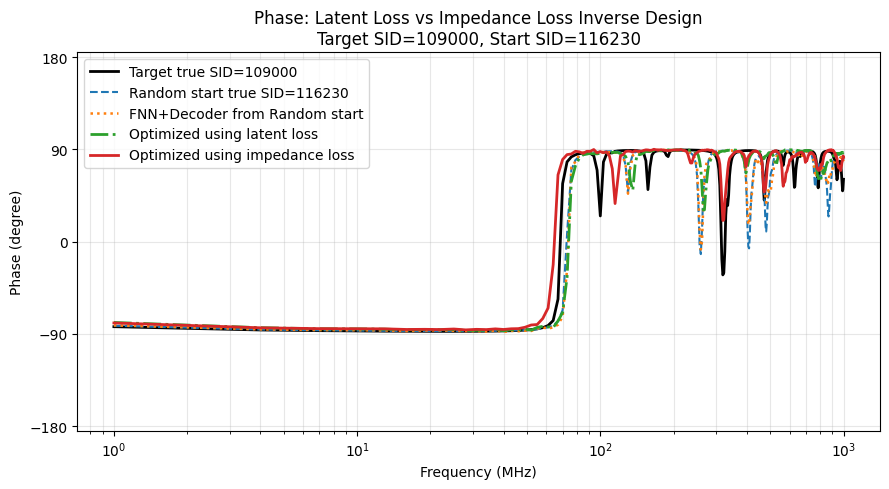

In [86]:
# Cell 21B - Compare latent-loss optimization vs impedance-loss optimization phase

compare_phase_fig_path = os.path.join(
    RUN_RESULTS_DIR,
    "latent_vs_impedance_loss_phase.png"
)

plt.figure(figsize=(9, 5))

plt.semilogx(
    freq_mhz,
    np.rad2deg(target_phase),
    "k-",
    linewidth=2.0,
    label=f"Target true SID={TARGET_SID}",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(nearest_true_phase),
    "--",
    linewidth=1.5,
    label=f"Random start true SID={nearest_sid}",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(start_pred_phase),
    ":",
    linewidth=1.8,
    label="FNN+Decoder from Random start",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(opt_pred_phase),
    "-.",
    linewidth=2.0,
    label="Optimized using latent loss",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(opt_imp_pred_phase),
    "-",
    linewidth=2.0,
    label="Optimized using impedance loss",
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Phase (degree)")
plt.ylim(-185, 185)
plt.yticks([-180, -90, 0, 90, 180])
plt.title(
    f"Phase: Latent Loss vs Impedance Loss Inverse Design\n"
    f"Target SID={TARGET_SID}, Start SID={nearest_sid}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(compare_phase_fig_path, dpi=300, bbox_inches="tight")
print("Saved comparison phase plot:")
print(compare_phase_fig_path)

plt.show()

In [87]:
# Cell - Compact comparison table: latent loss vs impedance loss

comparison_loss_df = pd.DataFrame({
    "case": [
        "Random start true impedance",
        "Random start FNN+Decoder",
        "Optimized using latent loss",
        "Optimized using impedance loss",
    ],
    "mae_ohm": [
        nearest_true_mae_ohm,
        nearest_fnn_mae_ohm,
        opt_pred_mae_ohm,
        opt_imp_mae_ohm,
    ],
    "mae_db": [
        nearest_true_mae_db,
        nearest_fnn_mae_db,
        opt_pred_mae_db,
        opt_imp_mae_db,
    ],
})

display(comparison_loss_df)

save_comparison_csv = os.path.join(
    RUN_RESULTS_DIR,
    "loss_comparison.csv",
)

comparison_loss_df.to_csv(save_comparison_csv, index=False)

print("Saved loss comparison table:")
print(save_comparison_csv)

,case,mae_ohm,mae_db
0,Random start true impedance,0.810095,3.379093
1,Random start FNN+Decoder,0.729019,3.175661
2,Optimized using latent loss,0.568341,2.765016
3,Optimized using impedance loss,0.322493,1.527919


Saved loss comparison table:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/inverse_design_random_fnn_cnn_ae/target_109000_start_116230/loss_comparison.csv


# EM Validation

In [ ]:
# Cell EM-A - EM validation setup and file paths

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf

# Folder EM .s4p output files are stored
EM_INPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "Data",
    "inverse design validation output files"
)

# Folder where EM validation results will be saved
EM_RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "Results",
    "EM Validation"
)

os.makedirs(EM_RESULTS_DIR, exist_ok=True)

EM_VALIDATION_FILES = [
    {
        "target_sid": 100005,
        "start_sid": 116459,
        "s4p_file": "inverse_design_target_100005_nn_start_116459_geometry_out.s4p",
    },
    {
        "target_sid": 100500,
        "start_sid": 104930,
        "s4p_file": "inverse_design_target_100500_nn_start_104930_geometry_out.s4p",
    },
    {
        "target_sid": 101832,
        "start_sid": 119703,
        "s4p_file": "inverse_design_target_101832_nn_start_119703_geometry_out.s4p",
    },
    {
        "target_sid": 105000,
        "start_sid": 112859,
        "s4p_file": "inverse_design_target_105000_nn_start_112859_geometry_out.s4p",
    },
    {
        "target_sid": 106456,
        "start_sid": 107018,
        "s4p_file": "inverse_design_target_106456_nn_start_107018_geometry_out.s4p",
    },
    {
        "target_sid": 109276,
        "start_sid": 103334,
        "s4p_file": "inverse_design_target_109276_nn_start_103334_geometry_out.s4p",
    },
    {
        "target_sid": 111028,
        "start_sid": 119268,
        "s4p_file": "inverse_design_target_111028_nn_start_119268_geometry_out.s4p",
    },
]

print("EM input folder:")
print(EM_INPUT_DIR)

print("\nEM results folder:")
print(EM_RESULTS_DIR)

print("\nChecking .s4p files:")
for item in EM_VALIDATION_FILES:
    s4p_path = os.path.join(EM_INPUT_DIR, item["s4p_file"])
    print(
        f"Target {item['target_sid']} | Start {item['start_sid']} | "
        f"exists={os.path.exists(s4p_path)} | {s4p_path}"
    )

EM input folder:
/home/tekb/Master_Thesis_KB/CodesAndData/Data/inverse design validation output files

EM results folder:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/EM Validation

Checking .s4p files:
Target 100005 | Start 116459 | exists=True | /home/tekb/Master_Thesis_KB/CodesAndData/Data/inverse design validation output files/inverse_design_target_100005_nn_start_116459_geometry_out.s4p
Target 100500 | Start 104930 | exists=True | /home/tekb/Master_Thesis_KB/CodesAndData/Data/inverse design validation output files/inverse_design_target_100500_nn_start_104930_geometry_out.s4p
Target 101832 | Start 119703 | exists=True | /home/tekb/Master_Thesis_KB/CodesAndData/Data/inverse design validation output files/inverse_design_target_101832_nn_start_119703_geometry_out.s4p
Target 105000 | Start 112859 | exists=True | /home/tekb/Master_Thesis_KB/CodesAndData/Data/inverse design validation output files/inverse_design_target_105000_nn_start_112859_geometry_out.s4p
Target 106456 | Start 107

In [36]:
# Cell EM-B - Helper function to load Z11 from EM .s4p

def load_z11_from_s4p(s4p_path):
    """
    Load Z11 from an EM .s4p file using scikit-rf.

    Returns:
        freq_hz   : frequency array [F]
        z11       : complex Z11 [F]
        mag_ohm   : |Z11| [F]
        phase_rad : phase(Z11) [F]
    """

    ntwk = rf.Network(s4p_path)

    freq_hz = ntwk.f          # Hz
    z = ntwk.z                # [F, ports, ports]
    z11 = z[:, 0, 0]          # Z11, port 1 self impedance

    mag_ohm = np.abs(z11)
    phase_rad = np.angle(z11)

    return freq_hz, z11, mag_ohm, phase_rad

In [37]:
# Cell EM-C - Select one EM validation target and load data

TARGET_EM_SID = 100005   # change this to 100005, 101832, 105000, ...

# Find matching entry
matches = [
    item for item in EM_VALIDATION_FILES
    if int(item["target_sid"]) == int(TARGET_EM_SID)
]

if len(matches) == 0:
    raise ValueError(f"No EM validation file entry found for TARGET_EM_SID={TARGET_EM_SID}")

info = matches[0]

START_SID = int(info["start_sid"])
s4p_path = os.path.join(EM_INPUT_DIR, info["s4p_file"])

if not os.path.exists(s4p_path):
    raise FileNotFoundError(f"EM .s4p file not found:\n{s4p_path}")

# Create result folder for this target/start
EM_RUN_RESULTS_DIR = os.path.join(
    EM_RESULTS_DIR,
    f"target_{TARGET_EM_SID}_start_{START_SID}"
)

os.makedirs(EM_RUN_RESULTS_DIR, exist_ok=True)

# Load target impedance from database/cache
target_mag, target_phase, target_y = get_true_impedance_by_sid(TARGET_EM_SID)

# Load nearest-start true impedance from database/cache
nearest_mag, nearest_phase, nearest_y = get_true_impedance_by_sid(START_SID)

# Load EM-simulated optimized impedance
em_freq_hz, em_z11, em_mag, em_phase = load_z11_from_s4p(s4p_path)
em_freq_mhz = em_freq_hz / 1e6

print("Target SID:", TARGET_EM_SID)
print("Start SID:", START_SID)
print("EM file:", s4p_path)
print("EM run results folder:", EM_RUN_RESULTS_DIR)
print("EM frequency points:", len(em_freq_hz))
print("Database frequency points:", len(freq_hz))

Target SID: 100005
Start SID: 116459
EM file: /home/tekb/Master_Thesis_KB/CodesAndData/Data/inverse design validation output files/inverse_design_target_100005_nn_start_116459_geometry_out.s4p
EM run results folder: /home/tekb/Master_Thesis_KB/CodesAndData/Results/EM Validation/target_100005_start_116459
EM frequency points: 334
Database frequency points: 334


In [38]:
# Cell EM-D - Check frequency grid compatibility

same_len = len(em_freq_hz) == len(freq_hz)
same_grid = same_len and np.allclose(em_freq_hz, freq_hz, rtol=1e-6, atol=1e-3)

print("Same number of frequency points:", same_len)
print("Same frequency grid:", same_grid)

if not same_grid:
    print("Warning: EM frequency grid differs from database grid.")
    print("Metrics below assume same frequency grid.")
    print("If this is False, interpolation should be added before computing metrics.")

Same number of frequency points: True
Same frequency grid: True


In [39]:
# Cell EM-E - Compute and save EM validation metrics

em_mae_ohm = mae_ohm(target_mag, em_mag)
em_mae_db = mae_db(target_mag, em_mag)

nearest_true_mae_ohm = mae_ohm(target_mag, nearest_mag)
nearest_true_mae_db = mae_db(target_mag, nearest_mag)

improvement_ohm = 100.0 * (nearest_true_mae_ohm - em_mae_ohm) / nearest_true_mae_ohm
improvement_db = 100.0 * (nearest_true_mae_db - em_mae_db) / nearest_true_mae_db

print("EM validation result")
print("--------------------")
print(f"Target SID                         : {TARGET_EM_SID}")
print(f"Nearest start SID                  : {START_SID}")
print(f"Nearest true vs target MAE         : {nearest_true_mae_ohm:.6f} Ohm | {nearest_true_mae_db:.6f} dB")
print(f"EM optimized vs target MAE         : {em_mae_ohm:.6f} Ohm | {em_mae_db:.6f} dB")
print(f"EM improvement over nearest true   : {improvement_ohm:.2f}% Ohm | {improvement_db:.2f}% dB")

em_validation_metrics = {
    "target_sid": int(TARGET_EM_SID),
    "nearest_start_sid": int(START_SID),
    "s4p_path": s4p_path,

    "nearest_true_mae_ohm": float(nearest_true_mae_ohm),
    "nearest_true_mae_db": float(nearest_true_mae_db),

    "em_optimized_mae_ohm": float(em_mae_ohm),
    "em_optimized_mae_db": float(em_mae_db),

    "em_improvement_over_nearest_ohm_pct": float(improvement_ohm),
    "em_improvement_over_nearest_db_pct": float(improvement_db),

    "same_frequency_grid": bool(same_grid),
    "n_freq_em": int(len(em_freq_hz)),
    "n_freq_database": int(len(freq_hz)),
}

em_metrics_path = os.path.join(
    EM_RUN_RESULTS_DIR,
    "metrics_em_validation.json"
)

with open(em_metrics_path, "w") as f:
    json.dump(em_validation_metrics, f, indent=2)

print("\nSaved EM validation metrics:")
print(em_metrics_path)

EM validation result
--------------------
Target SID                         : 100005
Nearest start SID                  : 116459
Nearest true vs target MAE         : 0.435658 Ohm | 1.804766 dB
EM optimized vs target MAE         : 0.472169 Ohm | 2.551964 dB
EM improvement over nearest true   : -8.38% Ohm | -41.40% dB

Saved EM validation metrics:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/EM Validation/target_100005_start_116459/metrics_em_validation.json


Saved EM magnitude plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/EM Validation/target_100005_start_116459/em_validation_magnitude.png


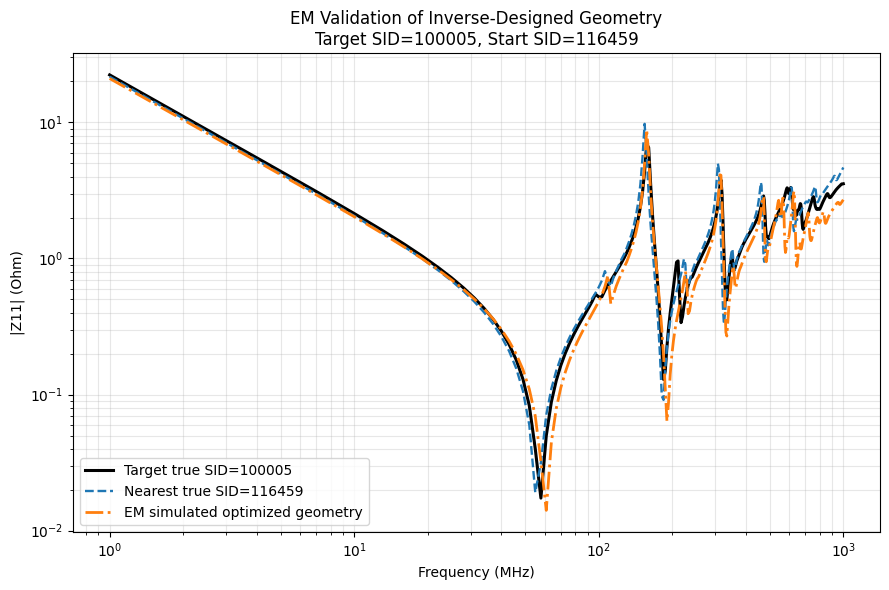

In [40]:
# Cell EM-F - Plot and save EM validation magnitude

em_mag_fig_path = os.path.join(
    EM_RUN_RESULTS_DIR,
    "em_validation_magnitude.png"
)

plt.figure(figsize=(9, 6))

plt.loglog(
    freq_mhz,
    target_mag,
    "k-",
    linewidth=2.2,
    label=f"Target true SID={TARGET_EM_SID}",
)

plt.loglog(
    freq_mhz,
    nearest_mag,
    "--",
    linewidth=1.7,
    label=f"Nearest true SID={START_SID}",
)

plt.loglog(
    em_freq_mhz,
    em_mag,
    "-.",
    linewidth=2.0,
    label="EM simulated optimized geometry",
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ohm)")
plt.title(
    f"EM Validation of Inverse-Designed Geometry\n"
    f"Target SID={TARGET_EM_SID}, Start SID={START_SID}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(em_mag_fig_path, dpi=300, bbox_inches="tight")

print("Saved EM magnitude plot:")
print(em_mag_fig_path)

plt.show()

Saved EM phase plot:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/EM Validation/target_100005_start_116459/em_validation_phase.png


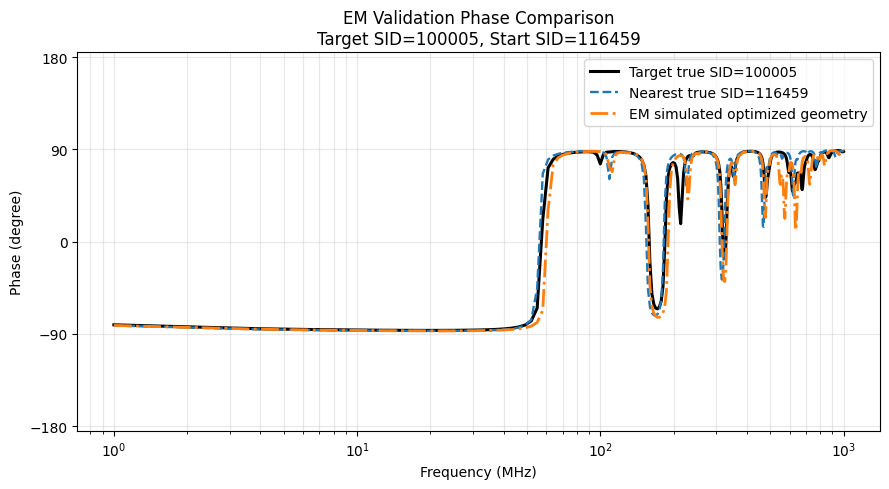

In [41]:
# Cell EM-G - Plot and save EM validation phase

em_phase_fig_path = os.path.join(
    EM_RUN_RESULTS_DIR,
    "em_validation_phase.png"
)

plt.figure(figsize=(9, 5))

plt.semilogx(
    freq_mhz,
    np.rad2deg(target_phase),
    "k-",
    linewidth=2.2,
    label=f"Target true SID={TARGET_EM_SID}",
)

plt.semilogx(
    freq_mhz,
    np.rad2deg(nearest_phase),
    "--",
    linewidth=1.7,
    label=f"Nearest true SID={START_SID}",
)

plt.semilogx(
    em_freq_mhz,
    np.rad2deg(em_phase),
    "-.",
    linewidth=2.0,
    label="EM simulated optimized geometry",
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Phase (degree)")
plt.ylim(-185, 185)
plt.yticks([-180, -90, 0, 90, 180])
plt.title(
    f"EM Validation Phase Comparison\n"
    f"Target SID={TARGET_EM_SID}, Start SID={START_SID}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(em_phase_fig_path, dpi=300, bbox_inches="tight")

print("Saved EM phase plot:")
print(em_phase_fig_path)

plt.show()

In [42]:
# Cell EM-H - Run EM validation for all files and save summary

all_em_results = []

for item in EM_VALIDATION_FILES:
    target_sid = int(item["target_sid"])
    start_sid = int(item["start_sid"])
    s4p_path_loop = os.path.join(EM_INPUT_DIR, item["s4p_file"])

    if not os.path.exists(s4p_path_loop):
        print(f"Skipping missing file: {s4p_path_loop}")
        continue

    run_dir = os.path.join(
        EM_RESULTS_DIR,
        f"target_{target_sid}_start_{start_sid}"
    )
    os.makedirs(run_dir, exist_ok=True)

    # Load data
    target_mag_loop, target_phase_loop, _ = get_true_impedance_by_sid(target_sid)
    nearest_mag_loop, nearest_phase_loop, _ = get_true_impedance_by_sid(start_sid)
    em_freq_hz_loop, em_z11_loop, em_mag_loop, em_phase_loop = load_z11_from_s4p(s4p_path_loop)
    em_freq_mhz_loop = em_freq_hz_loop / 1e6

    # Frequency grid check
    same_len_loop = len(em_freq_hz_loop) == len(freq_hz)
    same_grid_loop = same_len_loop and np.allclose(em_freq_hz_loop, freq_hz, rtol=1e-6, atol=1e-3)

    if not same_grid_loop:
        print(f"Warning: frequency grid mismatch for target {target_sid}")

    # Metrics
    nearest_ohm_loop = mae_ohm(target_mag_loop, nearest_mag_loop)
    nearest_db_loop = mae_db(target_mag_loop, nearest_mag_loop)

    em_ohm_loop = mae_ohm(target_mag_loop, em_mag_loop)
    em_db_loop = mae_db(target_mag_loop, em_mag_loop)

    improvement_ohm_loop = 100.0 * (nearest_ohm_loop - em_ohm_loop) / nearest_ohm_loop
    improvement_db_loop = 100.0 * (nearest_db_loop - em_db_loop) / nearest_db_loop

    result = {
        "target_sid": target_sid,
        "nearest_start_sid": start_sid,
        "nearest_true_mae_ohm": float(nearest_ohm_loop),
        "nearest_true_mae_db": float(nearest_db_loop),
        "em_optimized_mae_ohm": float(em_ohm_loop),
        "em_optimized_mae_db": float(em_db_loop),
        "em_improvement_over_nearest_ohm_pct": float(improvement_ohm_loop),
        "em_improvement_over_nearest_db_pct": float(improvement_db_loop),
        "same_frequency_grid": bool(same_grid_loop),
        "s4p_path": s4p_path_loop,
    }

    all_em_results.append(result)

    # Save individual metrics
    metrics_path_loop = os.path.join(run_dir, "metrics_em_validation.json")
    with open(metrics_path_loop, "w") as f:
        json.dump(result, f, indent=2)

    # Save magnitude plot
    mag_path_loop = os.path.join(run_dir, "em_validation_magnitude.png")

    plt.figure(figsize=(9, 6))
    plt.loglog(freq_mhz, target_mag_loop, "k-", linewidth=2.2, label=f"Target true SID={target_sid}")
    plt.loglog(freq_mhz, nearest_mag_loop, "--", linewidth=1.7, label=f"Nearest true SID={start_sid}")
    plt.loglog(em_freq_mhz_loop, em_mag_loop, "-.", linewidth=2.0, label="EM simulated optimized geometry")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("|Z11| (Ohm)")
    plt.title(f"EM Validation of Inverse-Designed Geometry\nTarget SID={target_sid}, Start SID={start_sid}")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(mag_path_loop, dpi=300, bbox_inches="tight")
    plt.close()

    # Save phase plot
    phase_path_loop = os.path.join(run_dir, "em_validation_phase.png")

    plt.figure(figsize=(9, 5))
    plt.semilogx(freq_mhz, np.rad2deg(target_phase_loop), "k-", linewidth=2.2, label=f"Target true SID={target_sid}")
    plt.semilogx(freq_mhz, np.rad2deg(nearest_phase_loop), "--", linewidth=1.7, label=f"Nearest true SID={start_sid}")
    plt.semilogx(em_freq_mhz_loop, np.rad2deg(em_phase_loop), "-.", linewidth=2.0, label="EM simulated optimized geometry")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Phase (degree)")
    plt.ylim(-185, 185)
    plt.yticks([-180, -90, 0, 90, 180])
    plt.title(f"EM Validation Phase Comparison\nTarget SID={target_sid}, Start SID={start_sid}")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(phase_path_loop, dpi=300, bbox_inches="tight")
    plt.close()

    print(
        f"Done target {target_sid}: "
        f"nearest={nearest_db_loop:.3f} dB, "
        f"EM={em_db_loop:.3f} dB, "
        f"improvement={improvement_db_loop:.2f}%"
    )

# Combined summary
em_results_df = pd.DataFrame(all_em_results)

summary_csv_path = os.path.join(
    EM_RESULTS_DIR,
    "em_validation_summary_all_targets.csv"
)

em_results_df.to_csv(summary_csv_path, index=False)

print("\nSaved combined EM validation summary:")
print(summary_csv_path)

display(
    em_results_df[
        [
            "target_sid",
            "nearest_start_sid",
            "nearest_true_mae_ohm",
            "nearest_true_mae_db",
            "em_optimized_mae_ohm",
            "em_optimized_mae_db",
            "em_improvement_over_nearest_ohm_pct",
            "em_improvement_over_nearest_db_pct",
            "same_frequency_grid",
        ]
    ].sort_values("em_improvement_over_nearest_db_pct", ascending=False)
)

Done target 100005: nearest=1.805 dB, EM=2.552 dB, improvement=-41.40%
Done target 100500: nearest=4.443 dB, EM=1.588 dB, improvement=64.27%
Done target 101832: nearest=2.038 dB, EM=2.029 dB, improvement=0.44%
Done target 105000: nearest=2.694 dB, EM=0.869 dB, improvement=67.76%
Done target 106456: nearest=3.639 dB, EM=2.266 dB, improvement=37.73%
Done target 109276: nearest=2.052 dB, EM=1.084 dB, improvement=47.17%
Done target 111028: nearest=1.608 dB, EM=1.134 dB, improvement=29.52%

Saved combined EM validation summary:
/home/tekb/Master_Thesis_KB/CodesAndData/Results/EM Validation/em_validation_summary_all_targets.csv


,target_sid,nearest_start_sid,nearest_true_mae_ohm,nearest_true_mae_db,em_optimized_mae_ohm,em_optimized_mae_db,em_improvement_over_nearest_ohm_pct,em_improvement_over_nearest_db_pct,same_frequency_grid
3,105000,112859,1.410948,2.693866,0.407933,0.868563,71.088039,67.757762,True
1,100500,104930,3.144703,4.443431,1.330118,1.587692,57.702908,64.268788,True
5,109276,103334,2.148845,2.052431,1.161973,1.084226,45.925693,47.173588,True
4,106456,107018,1.367189,3.638502,0.856173,2.265583,37.377113,37.733089,True
6,111028,119268,1.184857,1.608354,0.881788,1.133610,25.578569,29.517344,True
2,101832,119703,0.322060,2.037944,0.276042,2.028947,14.288607,0.441467,True
0,100005,116459,0.435658,1.804766,0.472169,2.551964,-8.380666,-41.401399,True
